In [1]:
import numpy as np
import jax.numpy as jnp
from dyn_modelling.models.cell_lattice import build_lattice, simulate_cell_lattice, compute_distance_matrix, compute_weights, compute_rhs, external_signal
from dyn_modelling.methods.neuralODE import init_vf_params, make_neural_ode, train_adam,train_SGD, solve_node,vf_forward
from dyn_modelling.utils.plots import plot_graph, plot_trajectories, plot_loss, plot_parameter_evolution, plot_predictions, plot_phase_portrait


## 1. Build the lattice


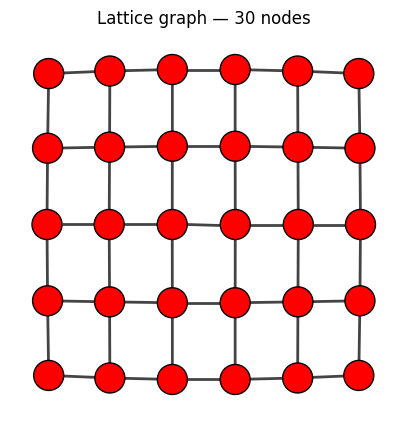

In [2]:
rows, cols = 5, 6
N = rows * cols

g = build_lattice(rows, cols)
plot_graph(g)

## 2. Simulate cell lattice - single trajectory 

In [3]:
# Parameters
a_params = np.array([2.4, 3.5, 2.0, 1.0])
l_params = np.array([1.0, 1.0, 0.2])
t_on, t_off = 10.0, 100.0
t_end, n_steps = 100.0, 100
neigh_order = 2

# Build RHS
dist_matrix = compute_distance_matrix(g)
rhs = compute_rhs(g, dist_matrix, l_params, neigh_order, t_on, t_off, a_params=a_params)


# Initial conditions
np.random.seed(1)
x0 = np.random.rand(N * 3)
t_eval = np.linspace(0, t_end, n_steps)

# Simulate
y = simulate_cell_lattice(rhs, x0, (0, t_end), t_eval)

## 3. Plot trajectories — clean data


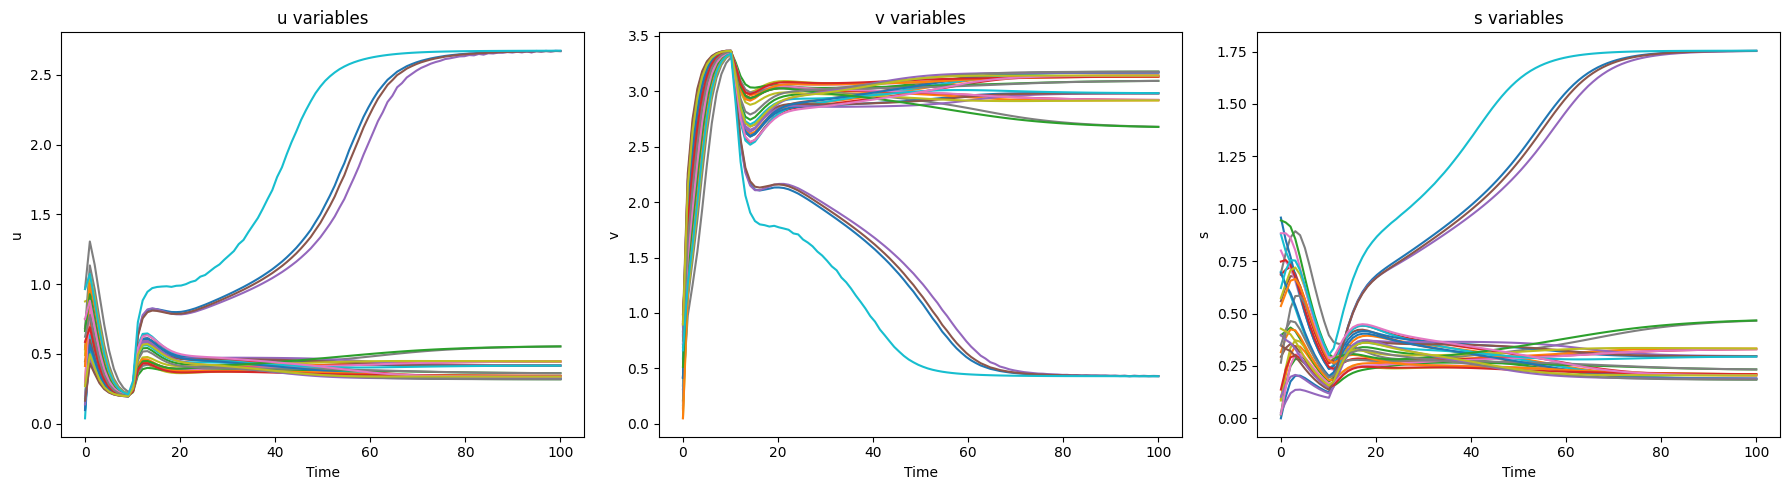

In [4]:
plot_trajectories(t_eval, y)

## 4. Plot trajectories — noisy data


In [5]:
#y_noisy = add_noise(y, noise_level=0.1)
#plot_trajectories(t_eval, y_noisy)

## 5. NeuralODE

In [6]:
ts = jnp.array(t_eval)       # (n_steps,)
y0 = jnp.array(y[:, 0])      # initial condition (3*N,)
y_true = jnp.array(y.T)      # (n_steps, 3*N)


np.random.seed(42)
vf_params = init_vf_params(data_size=3*N, width=64, depth=3)
loss_fn, grad_fn = make_neural_ode()

vf_params, loss_history = train_adam(
    vf_params, y0, ts, y_true,
    loss_fn, grad_fn,
    n_epochs=20_000, lr=1e-3
)

[     0] loss = 1.870865
[  2000] loss = 0.000847
[  4000] loss = 0.000521
[  6000] loss = 0.000099
[  8000] loss = 0.000178
[ 10000] loss = 0.000116
[ 12000] loss = 0.003321
[ 14000] loss = 0.000632
[ 16000] loss = 0.000296
[ 18000] loss = 0.000124


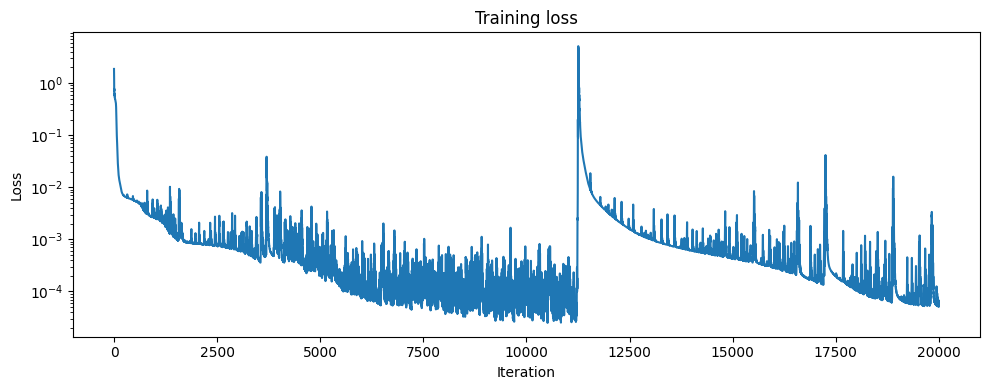

In [7]:
plot_loss(loss_history)

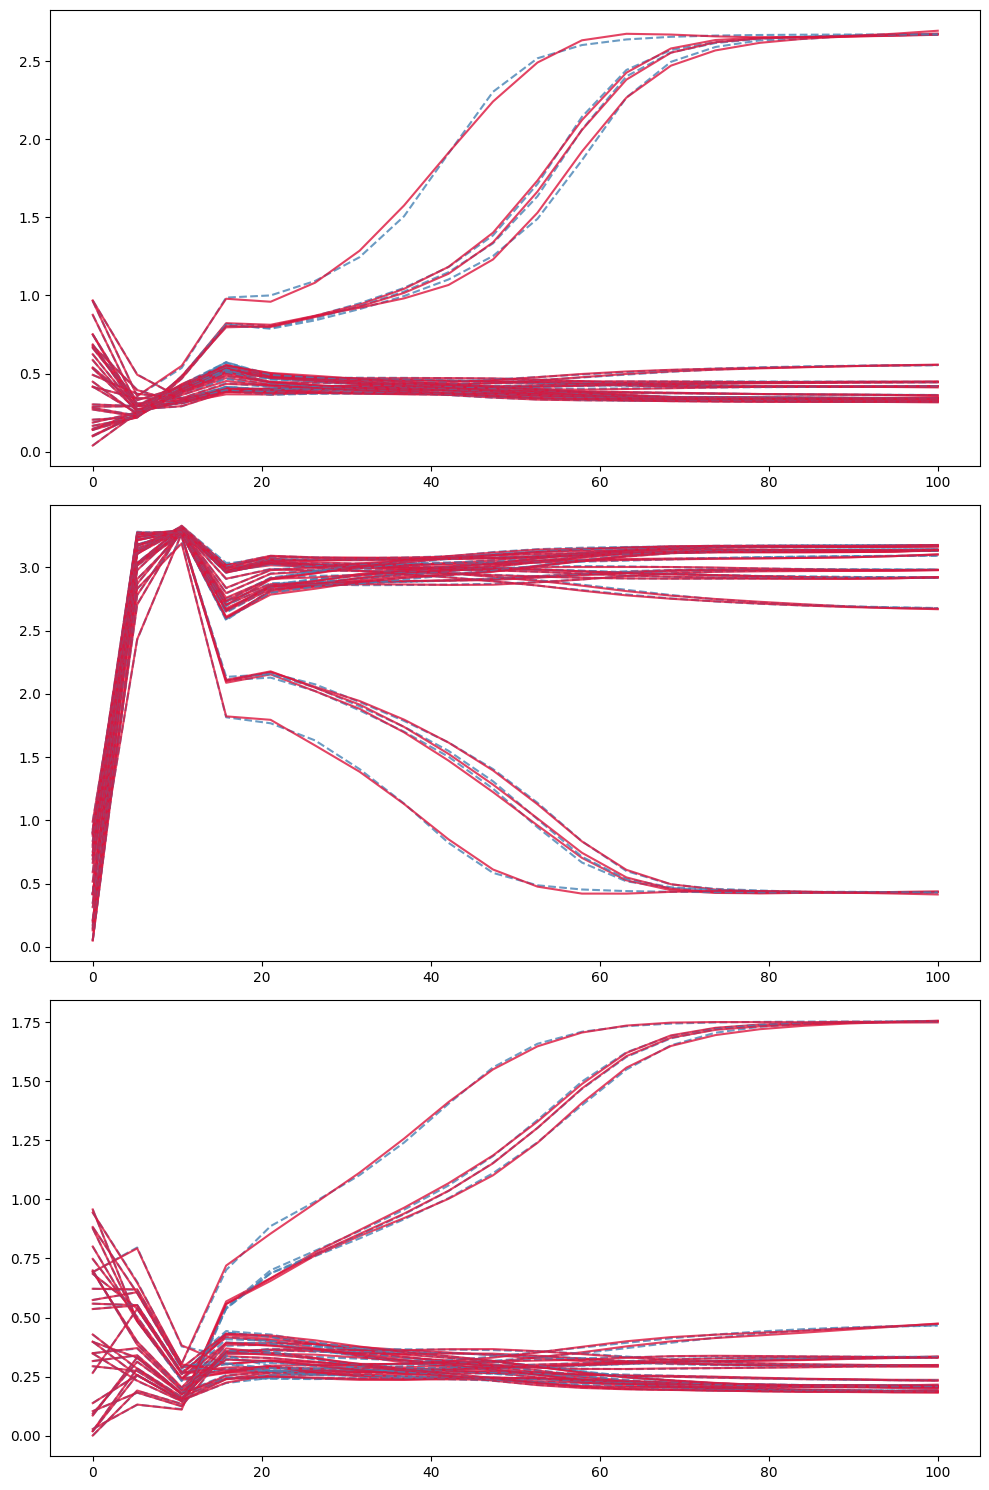

In [8]:

y_pred = np.array(solve_node(vf_params, y0, ts))  # (n_steps, 3*N)

plot_predictions(t_eval, y_pred, y_true)


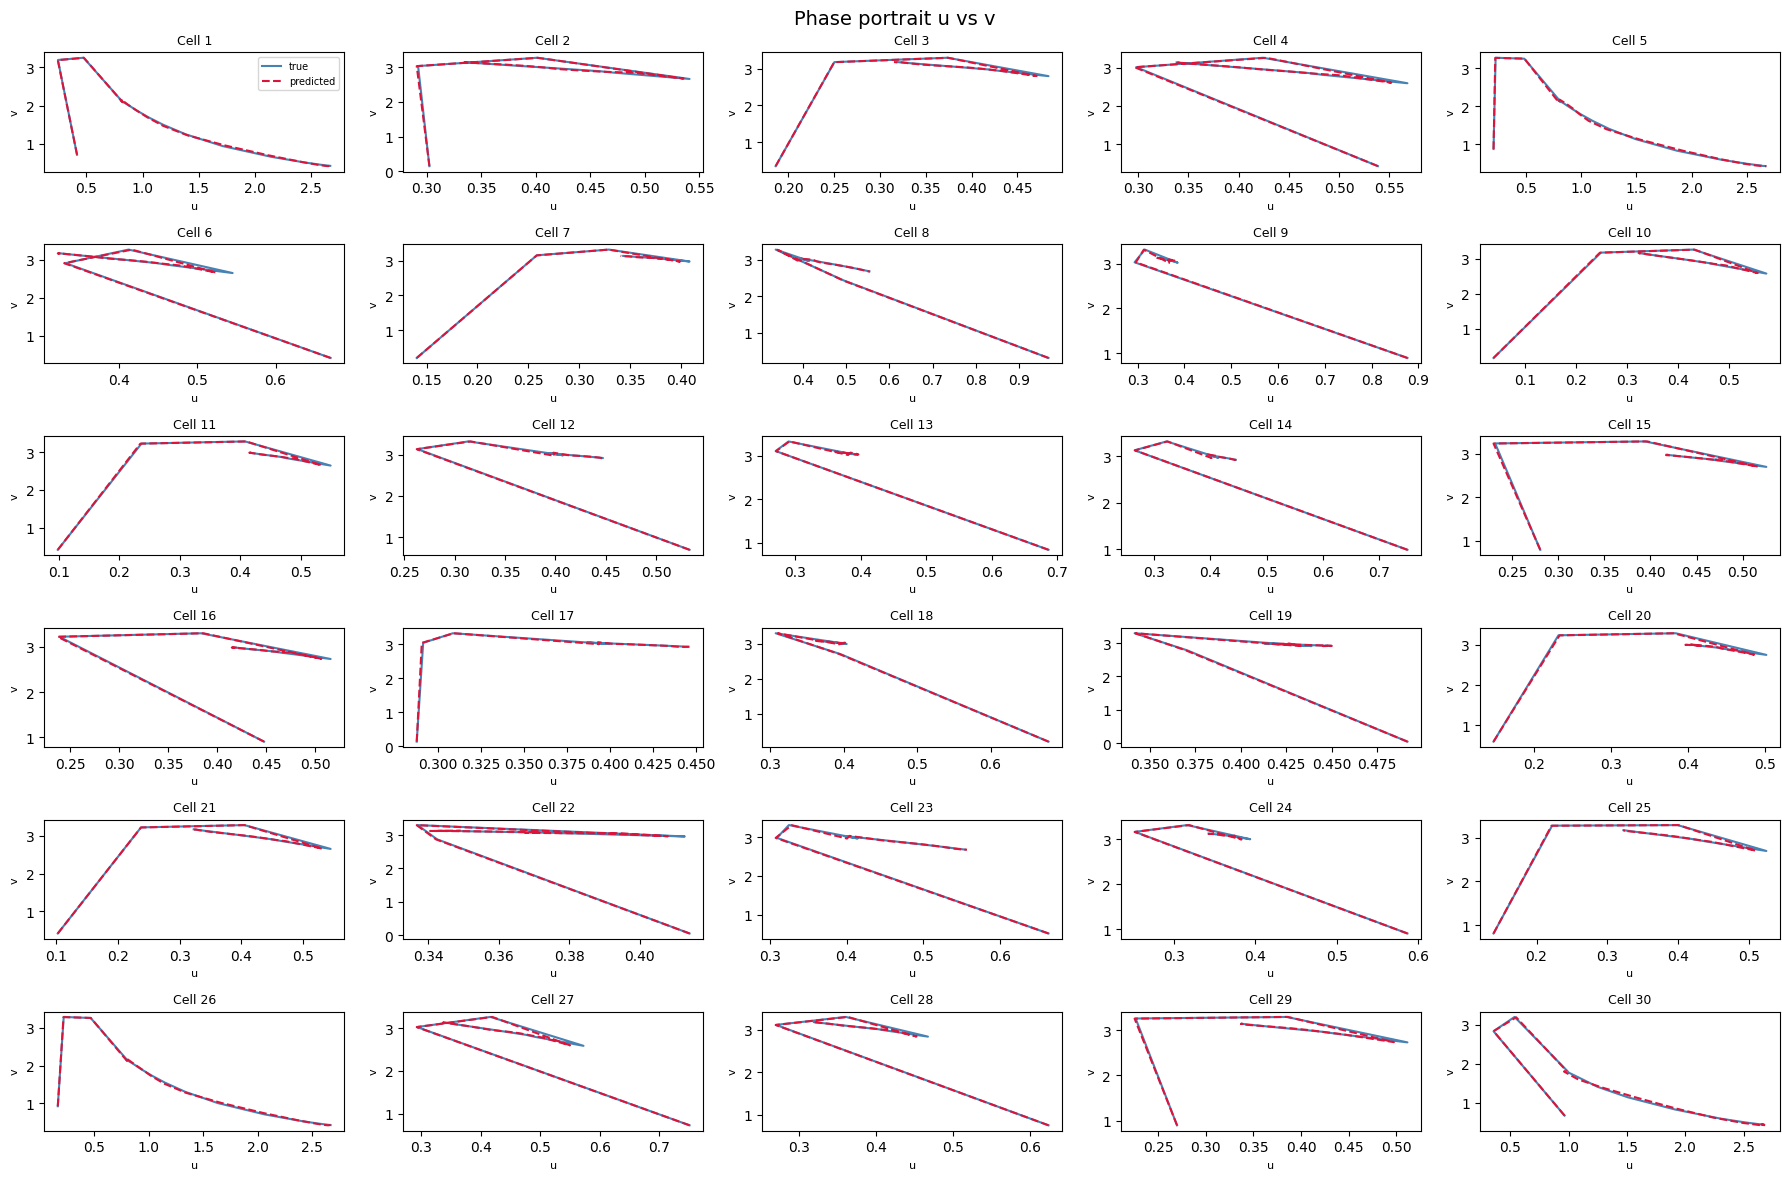

In [9]:
# phase portrait 
plot_phase_portrait(y_true, y_pred, n_cells=30)